# 18 — Convergence Curve Plots

**Maps to:** `report/Chapters/Task4.tex` §`T4:Convergence`.  
**Ticket:** TICKET-18.

Convergence curves showing mean ± 1 std of best fitness over generations.

**Part A:** Per-strategy comparison from TICKET-17 (repair vs. penalty vs. feasibility-preserving PMX).  
**Part B:** Per-configuration sensitivity from TICKET-16 parameter sweep.

---
## Setup

In [1]:
%run ./15_experiment_runner.ipynb

Loaded kroA100: 100 cities


Best fitness : 89127.80
Known optimal: 21,282
Gap          : 318.8%
Wall time    : 0.2s

Per-generation log (first 5 rows):
Saved: ../results/649a28b7_seed0042.csv
Size : 11,878 bytes
Shape: (101, 16)
Cols : ['generation', 'best_fitness', 'mean_fitness', 'diversity', 'pop_size', 'n_generations', 'crossover_rate', 'mutation_rate', 'tournament_k', 'elitism_count', 'selection_method', 'crossover_method', 'mutation_method', 'repair_enabled', 'repair_strategy', 'seed']
Grid: 6 configurations
  976d5e2d | xover=pmx seed=1
  976d5e2d | xover=pmx seed=2
  976d5e2d | xover=pmx seed=3
  0fc01629 | xover=ox seed=1
  0fc01629 | xover=ox seed=2
  0fc01629 | xover=ox seed=3
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.
Re-running the same grid (all should be skipped):
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.


In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.figsize": (8, 5),
    "figure.constrained_layout.use": True,
})

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPTIMAL = 21282  # kroA100 known optimal (TSPLIB)

---
## Load Benchmark

In [3]:
coords, dist_matrix = load_tsp(Path("../data/TSP-dataset/kroA100.tsp"))
n_cities = dist_matrix.shape[0]
print(f"Loaded kroA100: {n_cities} cities")

Loaded kroA100: 100 cities


---
# Part A — Per-Strategy Convergence (TICKET-17)

Three constraint-handling strategies compared using naive crossover.

In [4]:
from dataclasses import dataclass as _dc

@_dc
class PenaltyConfig(ExperimentConfig):
    penalty_weight: float = 0.0

N_SEEDS = 30
SEEDS = list(range(1, N_SEEDS + 1))

COMPARE_BASE = {
    "pop_size": 100,
    "n_generations": 500,
    "crossover_rate": 0.8,
    "mutation_rate": 0.2,
    "tournament_k": 3,
    "elitism_count": 2,
    "selection_method": "tournament",
    "crossover_method": "naive",
    "mutation_method": "swap",
}

compare_strategies = {
    "repair": (ExperimentConfig, {"repair_enabled": True, "repair_strategy": "random"}),
    "penalty": (PenaltyConfig, {"repair_enabled": False, "repair_strategy": "random", "penalty_weight": 50000.0}),
    "pmx": (ExperimentConfig, {"crossover_method": "pmx", "repair_enabled": False, "repair_strategy": "random"}),
}

compare_configs = {}
for name, (cls, overrides) in compare_strategies.items():
    compare_configs[name] = [cls(**{**COMPARE_BASE, **overrides, "seed": s}) for s in SEEDS]

print(f"Strategy configs: {', '.join(f'{k}={len(v)}' for k, v in compare_configs.items())}")

Strategy configs: repair=30, penalty=30, pmx=30


In [5]:
def load_gen_data(config_list, label):
    frames = []
    for c in config_list:
        path = result_path(c)
        if not path.exists():
            continue
        df = pd.read_csv(path)[["generation", "best_fitness", "mean_fitness", "diversity"]].copy()
        df["seed"] = c.seed
        df["strategy"] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

strategy_names = ["repair", "penalty", "pmx"]
compare_data = pd.concat([
    load_gen_data(compare_configs[s], s) for s in strategy_names
], ignore_index=True)

print(f"Loaded {len(compare_data):,} rows across {compare_data['strategy'].nunique()} strategies")

Loaded 45,090 rows across 3 strategies


### Per-Strategy: Best Fitness Convergence

Saved: ../results/figures/convergence_best_fitness.pdf


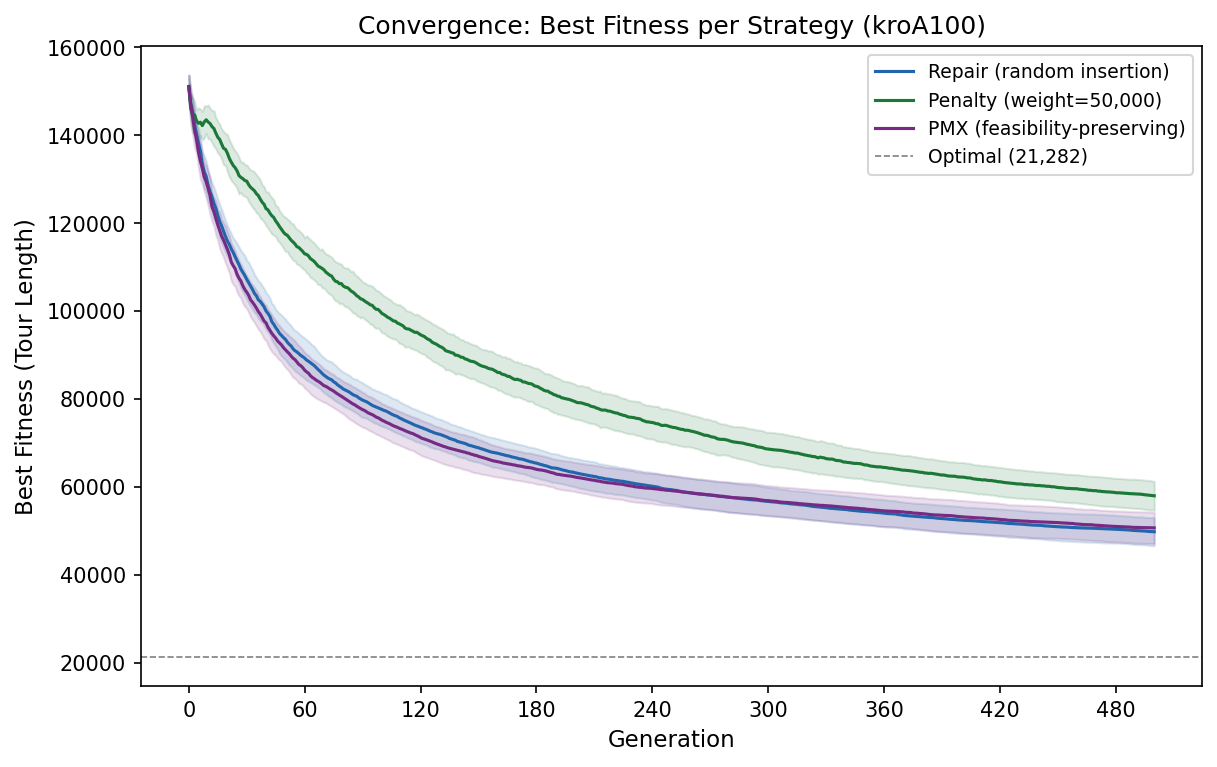

In [6]:
STRATEGY_STYLE = {
    "repair": {"color": "#2166ac", "label": "Repair (random insertion)"},
    "penalty": {"color": "#1b7837", "label": "Penalty (weight=50,000)"},
    "pmx": {"color": "#762a83", "label": "PMX (feasibility-preserving)"},
}

fig, ax = plt.subplots()
for strategy, style in STRATEGY_STYLE.items():
    subset = compare_data[compare_data["strategy"] == strategy]
    agg = subset.groupby("generation")["best_fitness"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], color=style["color"], linewidth=1.5, label=style["label"])
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    color=style["color"], alpha=0.15)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Convergence: Best Fitness per Strategy (kroA100)")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

path = FIGURES_DIR / "convergence_best_fitness.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Per-Strategy: Mean Population Fitness

Saved: ../results/figures/convergence_mean_fitness.pdf


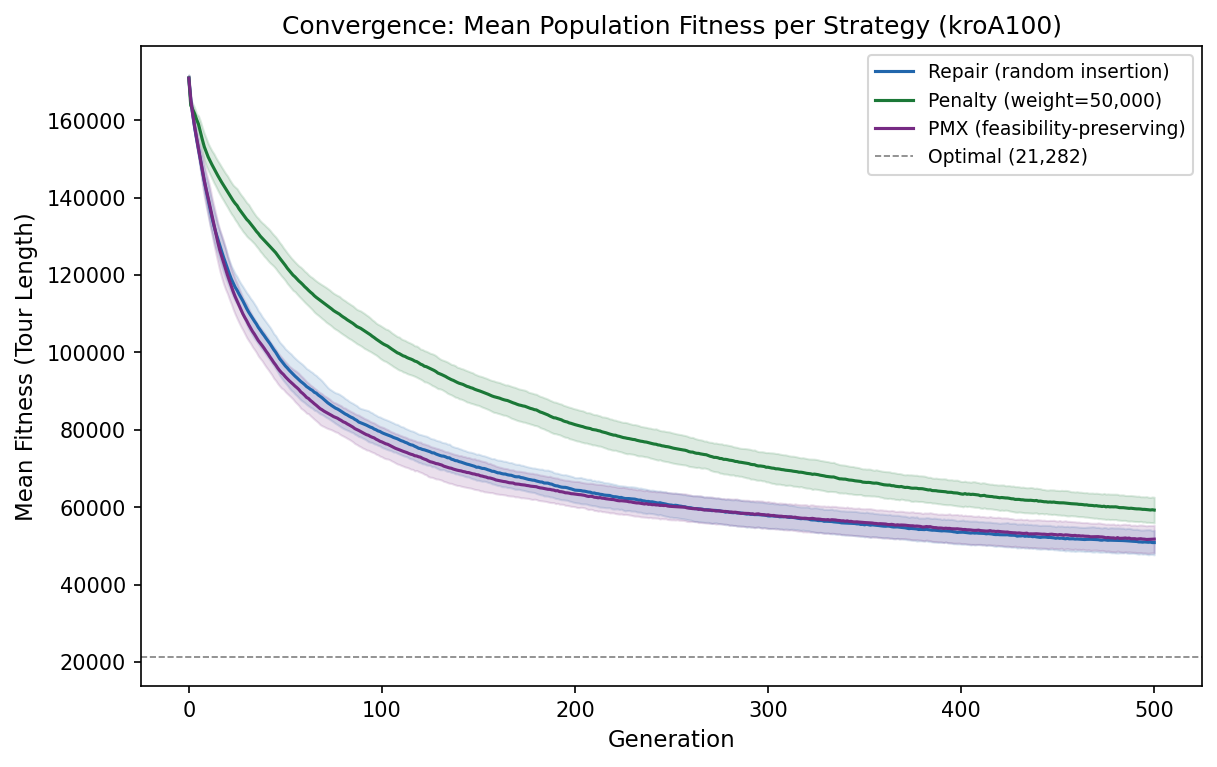

In [7]:
fig, ax = plt.subplots()
for strategy, style in STRATEGY_STYLE.items():
    subset = compare_data[compare_data["strategy"] == strategy]
    agg = subset.groupby("generation")["mean_fitness"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], color=style["color"], linewidth=1.5, label=style["label"])
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    color=style["color"], alpha=0.15)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Mean Fitness (Tour Length)")
ax.set_title("Convergence: Mean Population Fitness per Strategy (kroA100)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "convergence_mean_fitness.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Per-Strategy: Population Diversity

Saved: ../results/figures/convergence_diversity.pdf


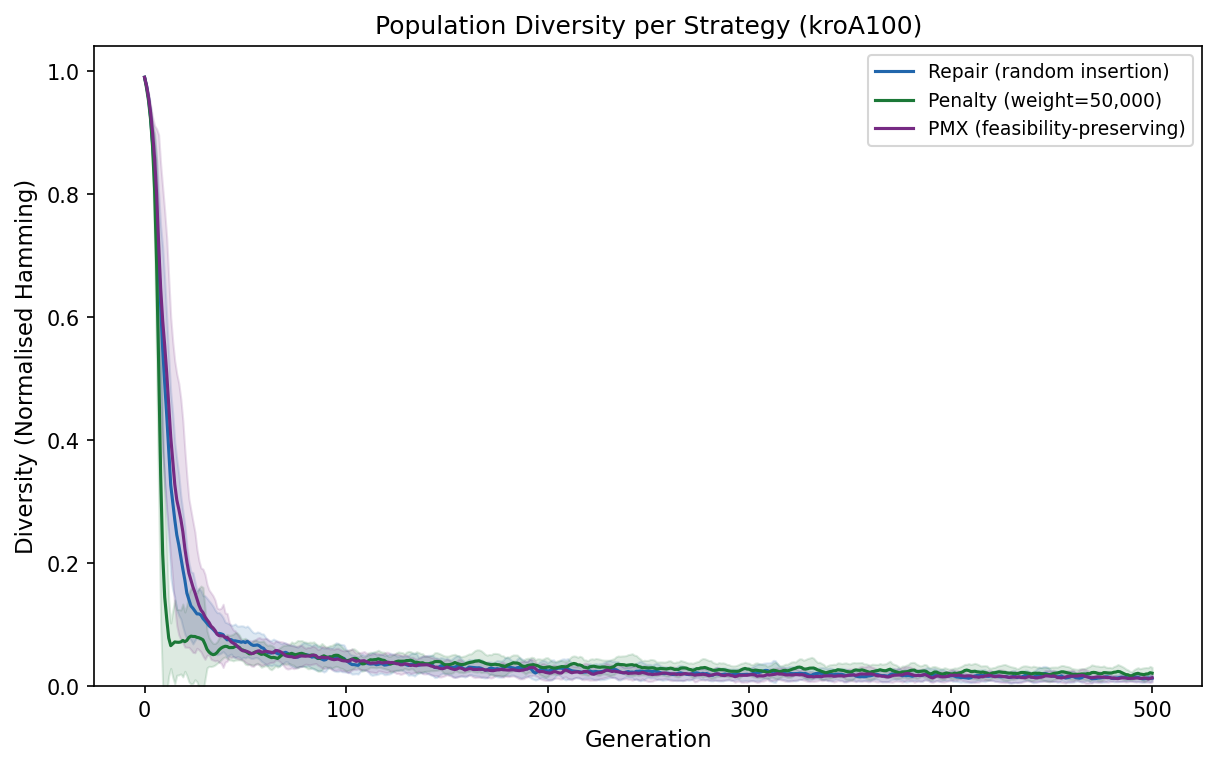

In [8]:
fig, ax = plt.subplots()
for strategy, style in STRATEGY_STYLE.items():
    subset = compare_data[compare_data["strategy"] == strategy]
    agg = subset.groupby("generation")["diversity"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], color=style["color"], linewidth=1.5, label=style["label"])
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    color=style["color"], alpha=0.15)

ax.set_xlabel("Generation")
ax.set_ylabel("Diversity (Normalised Hamming)")
ax.set_title("Population Diversity per Strategy (kroA100)")
ax.legend(loc="upper right")
ax.set_ylim(bottom=0)

path = FIGURES_DIR / "convergence_diversity.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Per-Strategy: Combined Three-Panel Figure

Saved: ../results/figures/convergence_combined.pdf


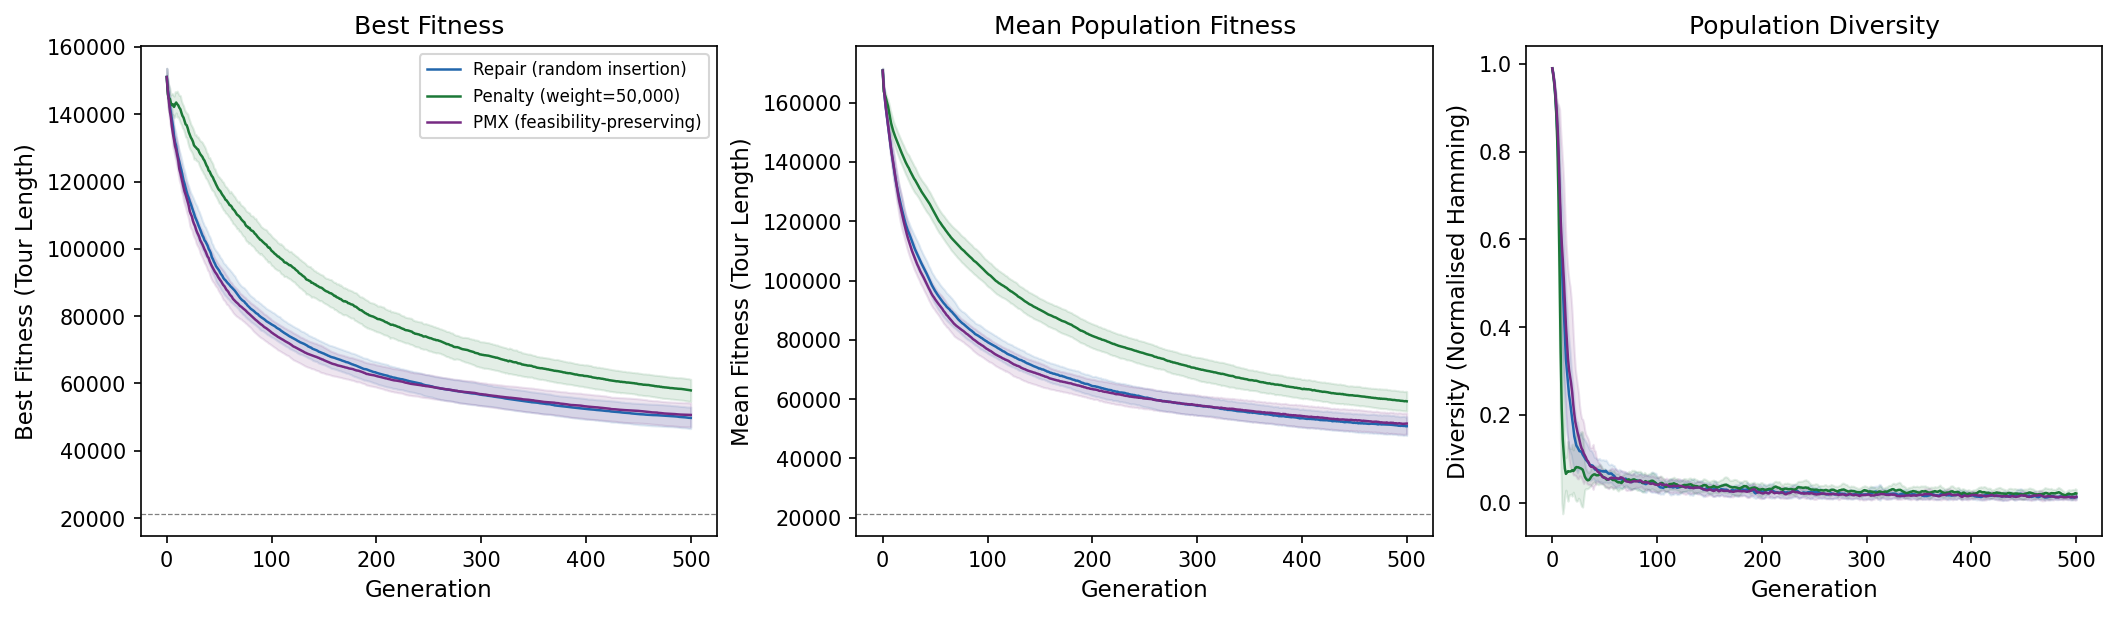

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [
    ("best_fitness", "Best Fitness (Tour Length)", "Best Fitness"),
    ("mean_fitness", "Mean Fitness (Tour Length)", "Mean Population Fitness"),
    ("diversity", "Diversity (Normalised Hamming)", "Population Diversity"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    for strategy, style in STRATEGY_STYLE.items():
        subset = compare_data[compare_data["strategy"] == strategy]
        agg = subset.groupby("generation")[col].agg(["mean", "std"]).reset_index()
        ax.plot(agg["generation"], agg["mean"], color=style["color"], linewidth=1.2, label=style["label"])
        ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                        color=style["color"], alpha=0.12)

    if col != "diversity":
        ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.6)

    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(loc="upper right", fontsize=8)

path = FIGURES_DIR / "convergence_combined.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
# Part B — Per-Configuration Convergence (TICKET-16)

Convergence curves grouped by key parameters from the sweep. All use naive
single-point crossover with repair enabled — the primary GA pipeline.

In [10]:
SWEEP_SEEDS = list(range(1, 31))

SWEEP_BASE = {
    "n_generations": 500,
    "tournament_k": 3,
    "elitism_count": 2,
    "crossover_method": "naive",
    "mutation_method": "swap",
    "repair_enabled": True,
    "repair_strategy": "random",
}

SWEEP_GRID = {
    "pop_size": [50, 100, 200],
    "crossover_rate": [0.7, 0.85, 0.95],
    "mutation_rate": [0.01, 0.05, 0.1],
    "selection_method": ["tournament", "roulette"],
}

sweep_configs = build_grid(SWEEP_GRID, SWEEP_SEEDS, SWEEP_BASE)
print(f"Sweep configs: {len(sweep_configs)} total ({len(sweep_configs) // 30} unique)")

Sweep configs: 1620 total (54 unique)


In [11]:
def load_sweep_convergence(param_name, param_value):
    frames = []
    for c in sweep_configs:
        if getattr(c, param_name) != param_value:
            continue
        path = result_path(c)
        if not path.exists():
            continue
        df = pd.read_csv(path)[["generation", "best_fitness"]].copy()
        df["seed"] = c.seed
        df[param_name] = param_value
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

### Convergence by Population Size

Saved: ../results/figures/convergence_by_pop_size.pdf


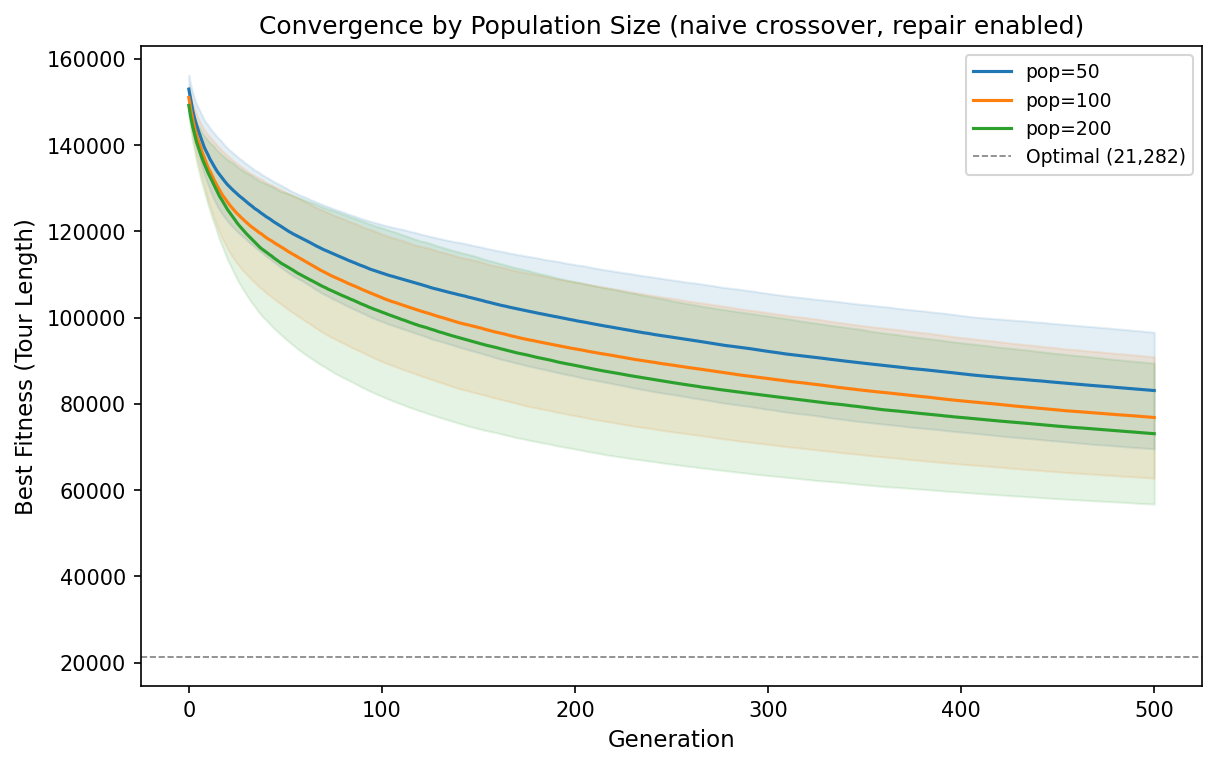

In [12]:
fig, ax = plt.subplots()
colors = {"50": "C0", "100": "C1", "200": "C2"}

for ps in [50, 100, 200]:
    data = load_sweep_convergence("pop_size", ps)
    agg = data.groupby("generation")["best_fitness"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], linewidth=1.5, label=f"pop={ps}", color=colors[str(ps)])
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    alpha=0.12, color=colors[str(ps)])

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Convergence by Population Size (naive crossover, repair enabled)")
ax.legend()

path = FIGURES_DIR / "convergence_by_pop_size.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Convergence by Mutation Rate

Saved: ../results/figures/convergence_by_mutation_rate.pdf


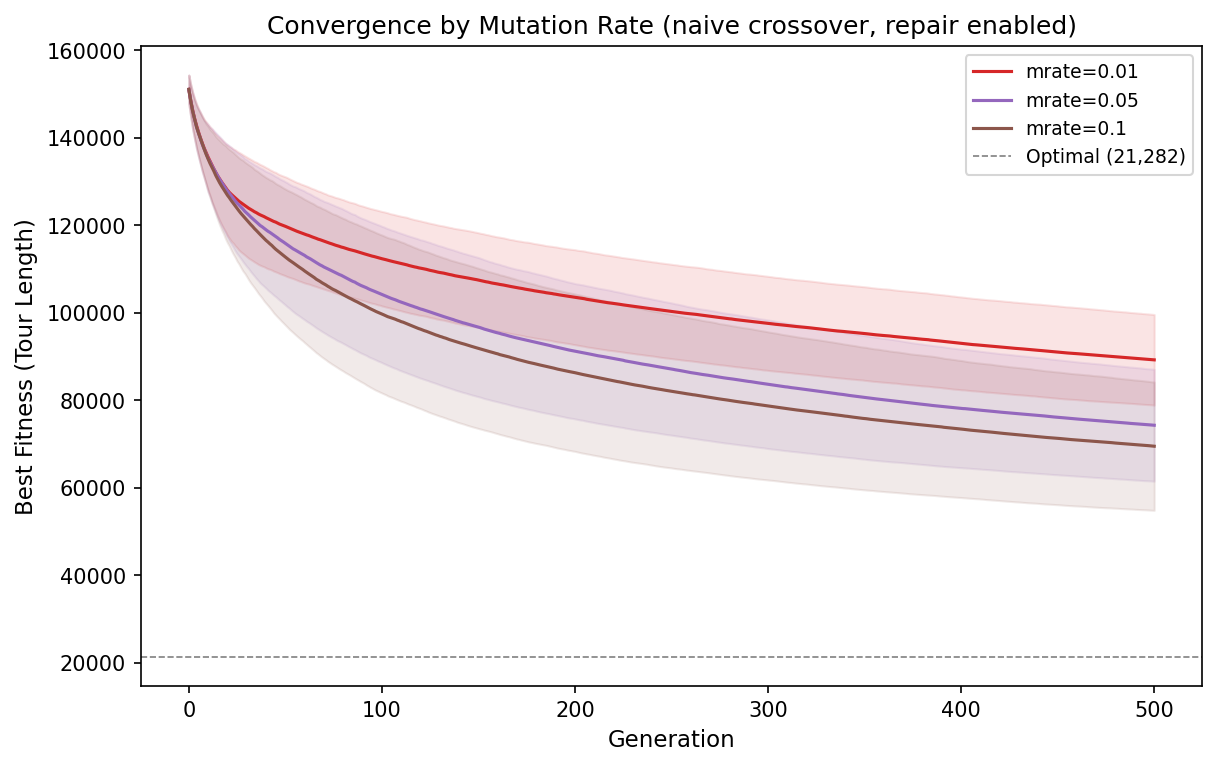

In [13]:
fig, ax = plt.subplots()
colors_mr = {"0.01": "C3", "0.05": "C4", "0.1": "C5"}

for mr in [0.01, 0.05, 0.1]:
    data = load_sweep_convergence("mutation_rate", mr)
    agg = data.groupby("generation")["best_fitness"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], linewidth=1.5, label=f"mrate={mr}", color=colors_mr[str(mr)])
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    alpha=0.12, color=colors_mr[str(mr)])

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Convergence by Mutation Rate (naive crossover, repair enabled)")
ax.legend()

path = FIGURES_DIR / "convergence_by_mutation_rate.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Convergence by Selection Method

Saved: ../results/figures/convergence_by_selection.pdf


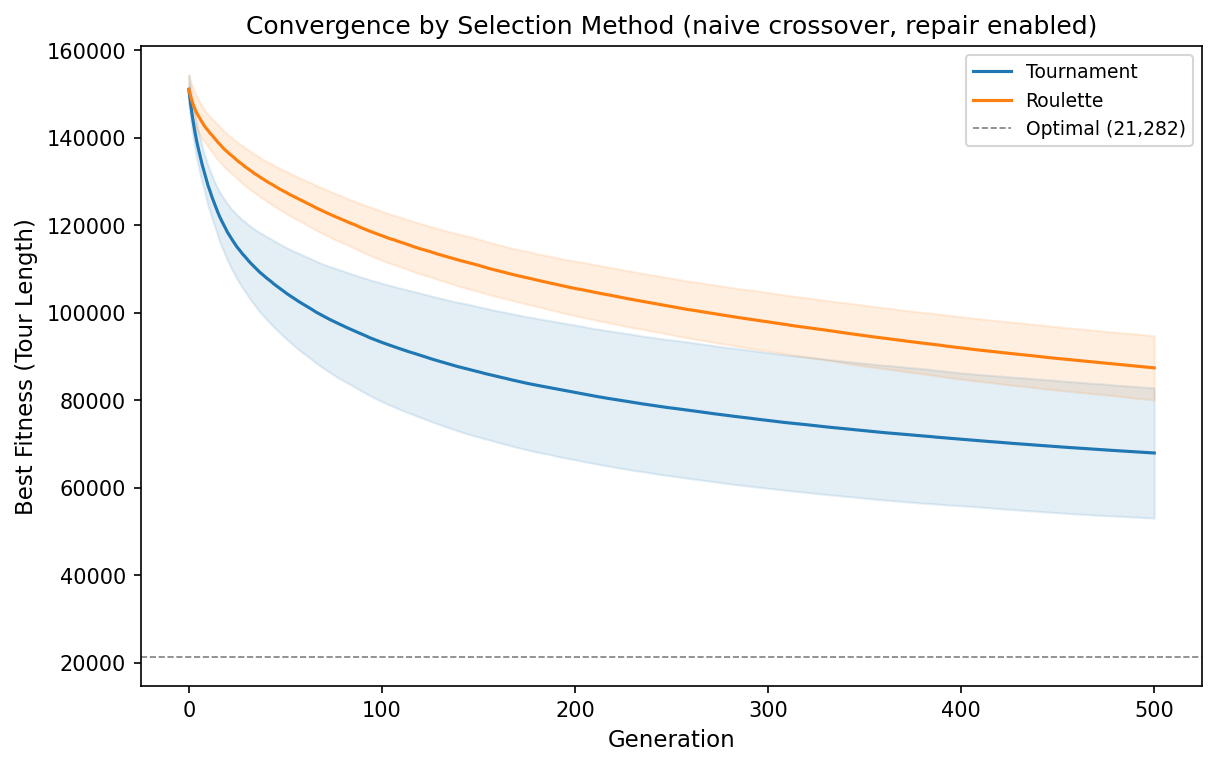

In [14]:
fig, ax = plt.subplots()

for method, color in [("tournament", "C0"), ("roulette", "C1")]:
    data = load_sweep_convergence("selection_method", method)
    agg = data.groupby("generation")["best_fitness"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], linewidth=1.5, label=method.capitalize(), color=color)
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    alpha=0.12, color=color)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Convergence by Selection Method (naive crossover, repair enabled)")
ax.legend()

path = FIGURES_DIR / "convergence_by_selection.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Convergence: Best vs Worst Configuration

Saved: ../results/figures/convergence_best_vs_worst.pdf


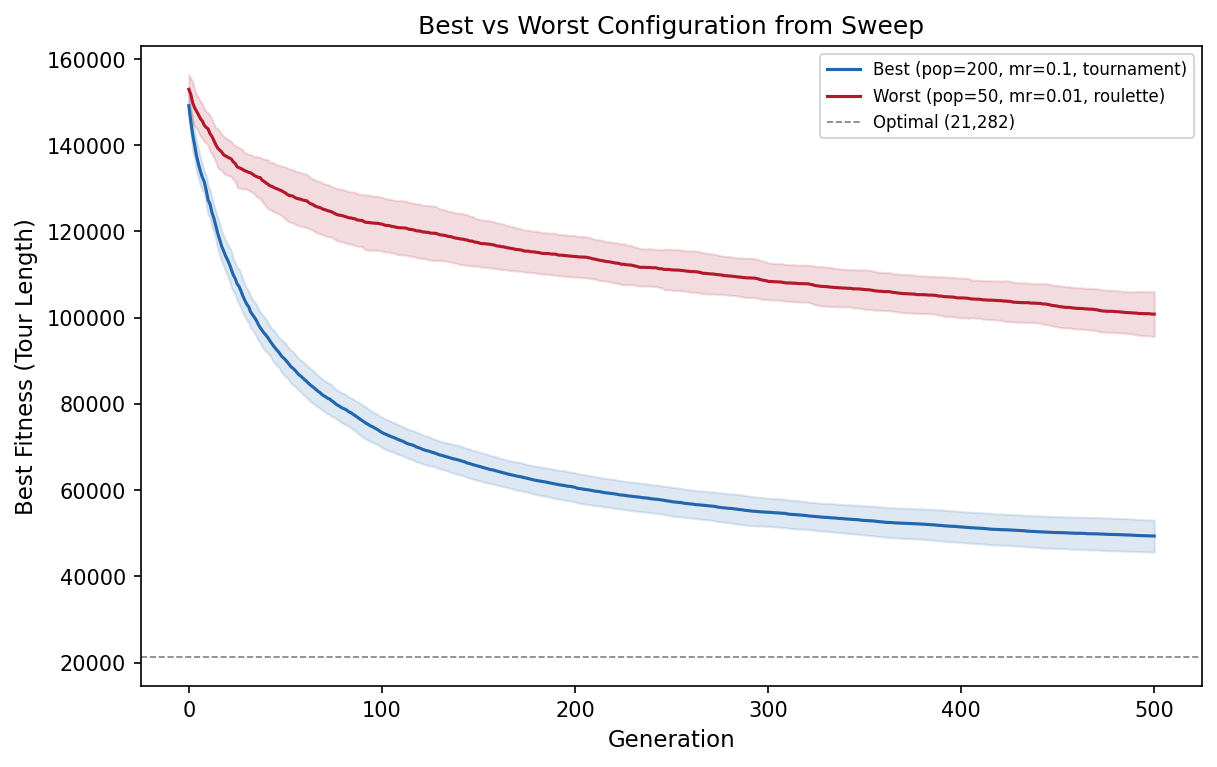

In [15]:
sweep_results = pd.read_csv(Path("../results/sweep_summary.csv"))
best_cfg = sweep_results.sort_values("mean").iloc[0]
worst_cfg = sweep_results.sort_values("mean").iloc[-1]

def load_config_convergence(pop_size, xrate, mrate, sel):
    frames = []
    for c in sweep_configs:
        if (c.pop_size == pop_size and c.crossover_rate == xrate
                and c.mutation_rate == mrate and c.selection_method == sel):
            path = result_path(c)
            if path.exists():
                df = pd.read_csv(path)[["generation", "best_fitness"]].copy()
                df["seed"] = c.seed
                frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

best_data = load_config_convergence(
    int(best_cfg["pop_size"]), best_cfg["crossover_rate"],
    best_cfg["mutation_rate"], best_cfg["selection_method"])
worst_data = load_config_convergence(
    int(worst_cfg["pop_size"]), worst_cfg["crossover_rate"],
    worst_cfg["mutation_rate"], worst_cfg["selection_method"])

fig, ax = plt.subplots()
for data, label, color in [
    (best_data, f"Best (pop={int(best_cfg['pop_size'])}, mr={best_cfg['mutation_rate']}, {best_cfg['selection_method']})", "#2166ac"),
    (worst_data, f"Worst (pop={int(worst_cfg['pop_size'])}, mr={worst_cfg['mutation_rate']}, {worst_cfg['selection_method']})", "#b2182b"),
]:
    agg = data.groupby("generation")["best_fitness"].agg(["mean", "std"]).reset_index()
    ax.plot(agg["generation"], agg["mean"], linewidth=1.5, label=label, color=color)
    ax.fill_between(agg["generation"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                    alpha=0.15, color=color)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Best vs Worst Configuration from Sweep")
ax.legend(fontsize=8)

path = FIGURES_DIR / "convergence_best_vs_worst.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Summary

This notebook produces convergence figures for the report:

**Part A — Per-Strategy (TICKET-17, three constraint-handling strategies):**
1. Best fitness convergence (repair vs. penalty vs. PMX)
2. Mean population fitness convergence
3. Population diversity over generations
4. Combined three-panel figure

**Part B — Per-Configuration (TICKET-16, naive crossover with repair):**
5. Convergence by population size (50 vs 100 vs 200)
6. Convergence by mutation rate (0.01 vs 0.05 vs 0.1)
7. Convergence by selection method (tournament vs roulette)
8. Best vs worst configuration from sweep

All figures saved to `results/figures/` at 300 DPI in PDF format.